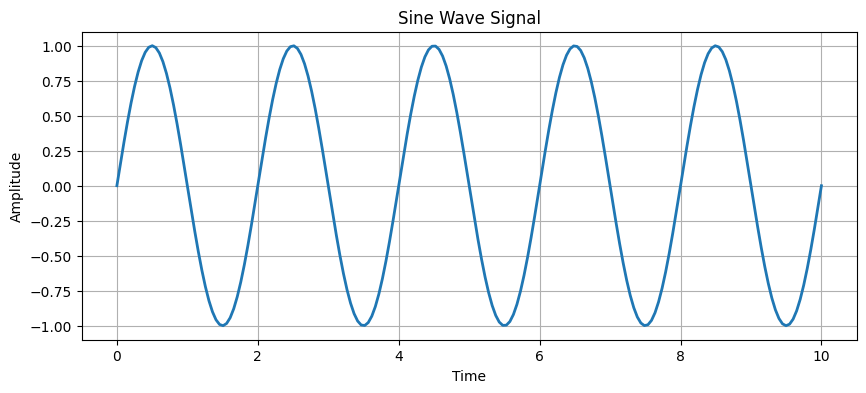

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# time axis
t = np.linspace(0, 10, 200)

# single sine signal
signal1 = np.sin(2 * np.pi * 0.5 * t)

# plot
plt.figure(figsize=(10, 4))
plt.plot(t, signal1, linewidth=2)
plt.title("Sine Wave Signal")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

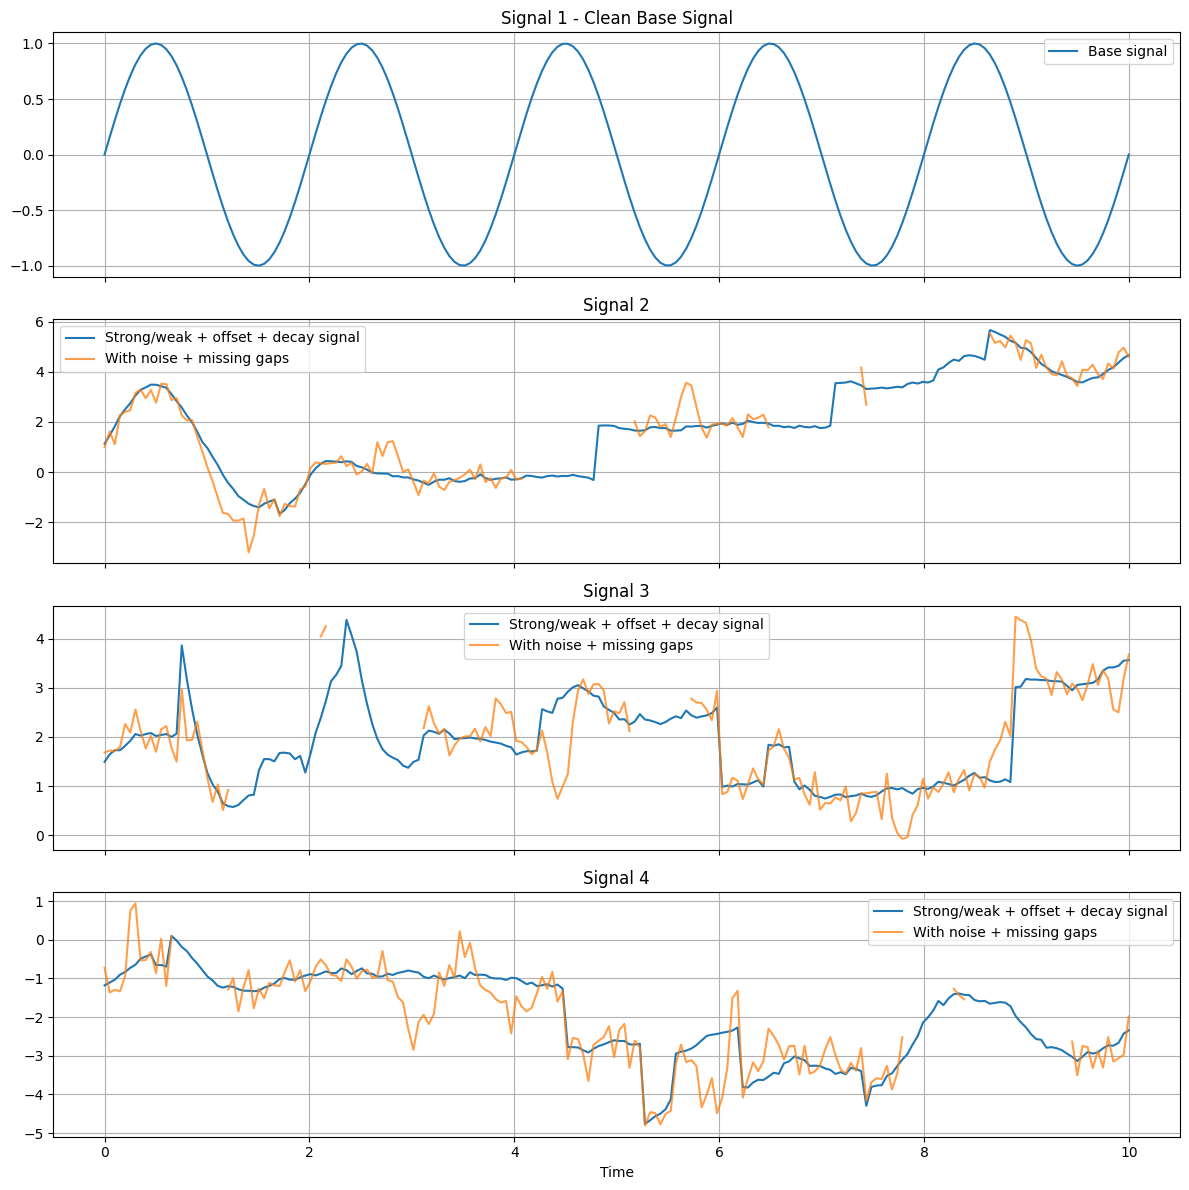

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

t = np.linspace(0, 10, 200)

signal1 = np.sin(2 * np.pi * 0.5 * t)


def random_signal(base_signal, t):
    N = len(t)

    # random-walk baseline
    random_steps = np.random.normal(0, 0.06, N)
    baseline_walk = np.cumsum(random_steps)

    # baseline shifts
    jump_points = np.random.choice(np.arange(10, N-10), size=5, replace=False)
    jump_points = np.sort(jump_points)

    offset = np.zeros(N)
    current_offset = np.random.uniform(-2.0, 2.0)

    start = 0
    for jp in jump_points:
        offset[start:jp] = current_offset
        current_offset += np.random.uniform(-2.5, 2.5)
        start = jp
    offset[start:] = current_offset

    # strong/weak amplitude regions
    amp = np.ones(N)

    amp_points = np.random.choice(np.arange(10, N-10), size=10, replace=False)
    amp_points = np.sort(amp_points)

    current_amp = np.random.uniform(0.2, 3.0)

    start = 0
    for ap in amp_points:
        amp[start:ap] = current_amp

        current_amp = np.random.choice([
            np.random.uniform(0.05, 0.3),   # very weak
            np.random.uniform(0.5, 1.2),    # normal
            np.random.uniform(2.0, 4.0)     # very strong
        ])

        start = ap
    amp[start:] = current_amp

    # local decay regions
    decay = np.ones(N)

    for _ in range(5):
        decay_start = np.random.randint(10, N-40)
        decay_length = np.random.randint(15, 50)

        end = min(decay_start + decay_length, N)

        local_decay = np.exp(-np.linspace(0, 3.5, end - decay_start))
        decay[decay_start:end] *= local_decay

    distorted = amp * decay * base_signal + offset + baseline_walk

    return distorted


def add_noise_and_gaps(signal,
                       noise_level=0.25,
                       n_spikes=8,
                       n_gaps=3,
                       min_gap=8,
                       max_gap=25):

    noisy = signal.copy()
    N = len(signal)

    noisy += noise_level * np.random.randn(N)

    varying_noise = (0.2 + 0.5 * np.sin(0.2 * t)) * np.random.randn(N)
    noisy += 0.15 * varying_noise

    for _ in range(n_spikes):
        center = np.random.randint(0, N)
        spike_amp = np.random.uniform(0.8, 2.0)

        if np.random.rand() < 0.5:
            spike_amp *= -1

        width = np.random.randint(2, 8)

        left = max(0, center - width)
        right = min(N, center + width)

        pulse = np.hanning(right - left)
        noisy[left:right] += spike_amp * pulse

    for _ in range(n_gaps):
        start = np.random.randint(0, N - max_gap)
        length = np.random.randint(min_gap, max_gap)

        noisy[start:start+length] = np.nan

    return noisy


signal2 = random_signal(signal1, t)
signal3 = random_signal(signal1, t)
signal4 = random_signal(signal1, t)

signal2_noisy = add_noise_and_gaps(signal2, noise_level=0.25)
signal3_noisy = add_noise_and_gaps(signal3, noise_level=0.20)
signal4_noisy = add_noise_and_gaps(signal4, noise_level=0.30)


fig, axs = plt.subplots(4, 1, figsize=(12, 12), sharex=True)

axs[0].plot(t, signal1, label="Base signal")
axs[0].set_title("Signal 1 - Clean Base Signal")
axs[0].legend()
axs[0].grid(True)

signals = [
    (signal2, signal2_noisy, "Signal 2"),
    (signal3, signal3_noisy, "Signal 3"),
    (signal4, signal4_noisy, "Signal 4")
]

for ax, (random_sig, noisy_sig, title) in zip(axs[1:], signals):
    ax.plot(t, random_sig, label="Strong/weak + offset + decay signal")
    ax.plot(t, noisy_sig, label="With noise + missing gaps", alpha=0.75)

    ax.set_title(title)
    ax.legend()
    ax.grid(True)

plt.xlabel("Time")
plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import numpy as np

df_signals = pd.DataFrame({
    "time": t,

    "signal2_clean": signal2,
    "signal2_noisy": signal2_noisy,

    "signal3_clean": signal3,
    "signal3_noisy": signal3_noisy,

    "signal4_clean": signal4,
    "signal4_noisy": signal4_noisy,
})

df_signals.to_csv("three_noisy_signals.csv", index=False)
print(df_signals.head())
print(df_signals.columns)

df = pd.read_csv("three_noisy_signals.csv")
print(df.columns)


       time  signal2_clean  signal2_noisy  signal3_clean  signal3_noisy  \
0  0.000000       1.135455       1.001286       1.494677       1.682292   
1  0.050251       1.463094       1.616492       1.647433       1.726360   
2  0.100503       1.829535       1.110718       1.732910       1.712260   
3  0.150754       2.231995       2.273823       1.730232       1.795313   
4  0.201005       2.504784       2.397601       1.819490       2.263011   

   signal4_clean  signal4_noisy  
0      -1.178319      -0.723035  
1      -1.103637      -1.360997  
2      -1.030490      -1.290629  
3      -0.901665      -1.334019  
4      -0.830806      -0.937873  
Index(['time', 'signal2_clean', 'signal2_noisy', 'signal3_clean',
       'signal3_noisy', 'signal4_clean', 'signal4_noisy'],
      dtype='str')
Index(['time', 'signal2_clean', 'signal2_noisy', 'signal3_clean',
       'signal3_noisy', 'signal4_clean', 'signal4_noisy'],
      dtype='str')


In [11]:
df["global_temperature"] = (
    df["signal2_clean"]
    + df["signal3_clean"]
    + df["signal4_clean"]
) / 3


print(df.head())

       time  signal2_clean  signal2_noisy  signal3_clean  signal3_noisy  \
0  0.000000       1.135455       1.001286       1.494677       1.682292   
1  0.050251       1.463094       1.616492       1.647433       1.726360   
2  0.100503       1.829535       1.110718       1.732910       1.712260   
3  0.150754       2.231995       2.273823       1.730232       1.795313   
4  0.201005       2.504784       2.397601       1.819490       2.263011   

   signal4_clean  signal4_noisy  global_temperature  
0      -1.178319      -0.723035            0.483937  
1      -1.103637      -1.360997            0.668963  
2      -1.030490      -1.290629            0.843985  
3      -0.901665      -1.334019            1.020187  
4      -0.830806      -0.937873            1.164489  
